# Scheduled Report Sender

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-engineering-bi/report-scheduler/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-engineering-bi/report-scheduler/demo.ipynb)

> Weekly reports sent by hand. This defines a report once, on a cron, and previews every scheduled send — a dry run that never emails.

Someone on every data team spends Monday morning rebuilding the same digest and pasting it into an
email. This encodes the report + its schedule as data, computes exactly when it fires, and renders
the body automatically. (Sending is left as the one deliberate manual step — safety first.)

**What this notebook covers**
1. A report defined as data (query + cron + recipients)
2. A minimal cron parser and next-run calculator
3. Rendering the report body as Markdown
4. A dry-run send plan for the coming week
5. The manual toil it removes, visualized


## Step 1 - Report as data + a cron parser

The schedule is a standard 5-field cron. We parse `*`, `*/n`, ranges, and lists, then scan forward
to find the next fire times - so "every Monday 9am" becomes actual datetimes.

In [1]:
from datetime import datetime
from scheduler import (next_runs, describe_cron, render_report, build_send_plan,
                       SAMPLE_REPORTS, sample_dataframe)

now = datetime(2026, 7, 25, 10, 0)
for cron in ["0 9 * * 1", "0 9 * * *", "0 8 1 * *", "*/15 * * * *"]:
    fires = next_runs(cron, now, 3)
    print(f"{cron:<14} {describe_cron(cron):<28} -> " +
          ", ".join(d.strftime("%a %m-%d %H:%M") for d in fires))


0 9 * * 1      Every Monday at 09:00        -> Mon 07-27 09:00, Mon 08-03 09:00, Mon 08-10 09:00
0 9 * * *      Every day at 09:00           -> Sun 07-26 09:00, Mon 07-27 09:00, Tue 07-28 09:00
0 8 1 * *      1st of each month at 08:00   -> Sat 08-01 08:00, Tue 09-01 08:00, Thu 10-01 08:00
*/15 * * * *   Every 15 minutes             -> Sat 07-25 10:15, Sat 07-25 10:30, Sat 07-25 10:45


## Step 2 - Render the digest

Given the report spec and the source data, the body writes itself: a headline total and a
group-by breakdown - the exact thing that was being assembled by hand.

In [2]:
df = sample_dataframe()
print(render_report(SAMPLE_REPORTS[0], df, now))


# Weekly Revenue Digest

_Generated 2026-07-25 10:00 · schedule: Every Monday at 09:00_

**Total amount:** 44,000

## amount by region

| region | sum(amount) |
|---|---|
| US | 21,000 |
| EU | 15,000 |
| APAC | 8,000 |

---
_To: exec@acme.com, finance@acme.com_


## Step 3 - The dry-run send plan

Across all configured reports, exactly what would go out in the next 7 days - and to how many
people. This is the review step: eyeball it before anything is ever wired to a mail server.

In [3]:
plan = build_send_plan(SAMPLE_REPORTS, now, horizon_days=7)
print(plan.to_string(index=False))
print(f"\nTotal sends this week: {len(plan)}")


               report         fires_at  recipients                   schedule
        Daily Signups 2026-07-26 09:00           1         Every day at 09:00
Weekly Revenue Digest 2026-07-27 09:00           2      Every Monday at 09:00
        Daily Signups 2026-07-27 09:00           1         Every day at 09:00
        Daily Signups 2026-07-28 09:00           1         Every day at 09:00
        Daily Signups 2026-07-29 09:00           1         Every day at 09:00
        Daily Signups 2026-07-30 09:00           1         Every day at 09:00
        Daily Signups 2026-07-31 09:00           1         Every day at 09:00
   Monthly Board Pack 2026-08-01 08:00           1 1st of each month at 08:00
        Daily Signups 2026-08-01 09:00           1         Every day at 09:00

Total sends this week: 9


## Step 4 - The toil removed, visualized

Count the manual sends per report per week. Every bar is time a human was copy-pasting a report
that now assembles itself.

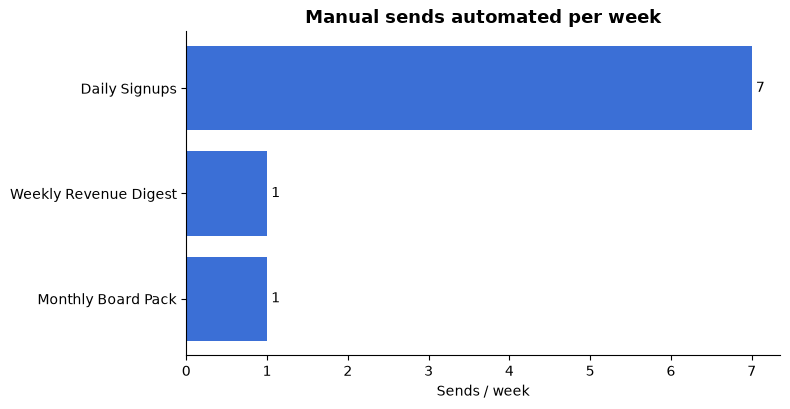

In [4]:
import matplotlib.pyplot as plt

counts = plan.groupby("report").size().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(counts.index, counts.values, color="#3b6fd6")
ax.set_title("Manual sends automated per week", fontsize=13, weight="bold")
ax.set_xlabel("Sends / week")
ax.bar_label(bars, padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("send_frequency.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Piece | Job |
|-------|-----|
| ScheduledReport | report spec: query + cron + recipients |
| next_runs / cron parser | when it fires |
| render_report | the digest body |
| build_send_plan | dry-run preview of upcoming sends |

Everything except the actual send is automated - and the send is left explicit on purpose, because
firing email on a schedule is exactly the kind of side effect you want a human (or a reviewed
deploy) to own.

**Extend it:** wire `render_report` to your mail/Slack provider inside a real scheduler (cron,
Airflow, GitHub Actions), and log each send for an audit trail.

In [5]:
# --- Try your own report ---
# from scheduler import ScheduledReport
# r = ScheduledReport("My Report", "0 17 * * 5", ["me@co.com"], metric="amount", group_by="plan")
# print("Next Fridays 5pm:", [d.strftime("%m-%d %H:%M") for d in next_runs(r.cron, now, 3)])
# print(render_report(r, df, now))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) - Day 106,
Month 11: Analytics Engineering & BI.

**Run the app:** `pip install -r requirements.txt && streamlit run app.py`